**Customer Segmentation Using K-Means Clustering**

Customer segmentation is simply grouping customers with similar characteristics. These characteristics include geography, demography, behavioural, purchasing power, situational factors, personality, lifestyle, psychographic, etc. The goals of customer segmentation are customer acquisition, customer retention, increasing customer profitability, customer satisfaction, resource allocation by designing marketing measures or programs and improving target marketing measures.

Clustering is an efficient technique used for customer segmentation. Clustering places homogenous data points in a given dataset. Each of these groups is called a cluster. While the objects in each cluster are similar between themselves, they are dissimilar to the objects of other groups. Clustering is a type of data mining approach in machine learning classified under unsupervised learning. This is because it is able to discover patterns and information from unlabelled data. It is used extensively in machine learning, classification, and pattern recognition .

Clustering algorithms include the K-means algorithm, hierarchical clustering, DBSCAN. In this project, the k-means clustering algorithm has been applied in customer segmentation. K-means is a clustering algorithm based on the principle of partition. The letter k represents the number of clusters chosen. It is the most common centroid-based algorithm.

The steps of K-means clustering are :

1. Determine the number of clusters (k).
2. Select initial centroids.
3. Map each data point into the nearest cluster (most similar to centroid).
4. Update the mean value (centroid) of each cluster.
5. Repeat step 3–4 until all centroids are not changed.

Let’s jump right in!

Problem Statement
A retail store wants to get insights about its customers. And then build a system that can cluster customers into different groups.

About the dataset
The dataset can be downloaded from the kaggle website which can be found here.

The data includes the following features:

1. Customer ID
2. Customer Gender
3. Customer Age
4. Annual Income of the customer (in Thousand Dollars)
5. Spending score of the customer (based on customer behaviour and spending nature)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import plotly.express as px

# Load the dataset
customers_data = pd.read_csv("Customers.csv")

In [11]:
# Display the first few rows to inspect the structure
print("First five rows of the dataset:")
print(customers_data.head())

First five rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [12]:
# Check for missing values
print("\nMissing values in dataset:")
print(customers_data.isnull().sum())


Missing values in dataset:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
# Summary statistics
print("\nSummary statistics:")
print(customers_data.describe())


Summary statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


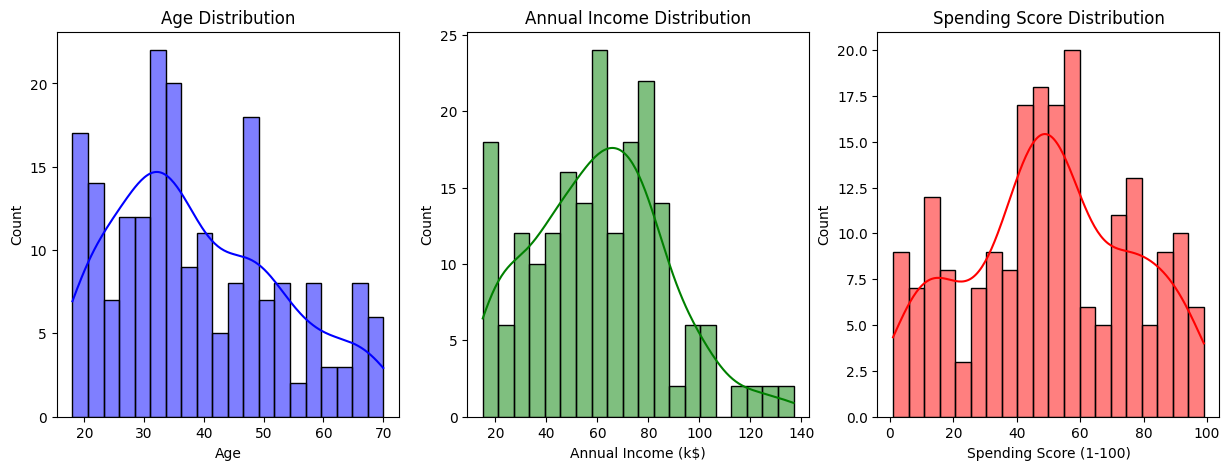

In [14]:
# Visualizing the distribution of Age, Annual Income, and Spending Score
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(customers_data['Age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(customers_data['Annual Income (k$)'], bins=20, kde=True, color='green')
plt.title('Annual Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(customers_data['Spending Score (1-100)'], bins=20, kde=True, color='red')
plt.title('Spending Score Distribution')

plt.show()

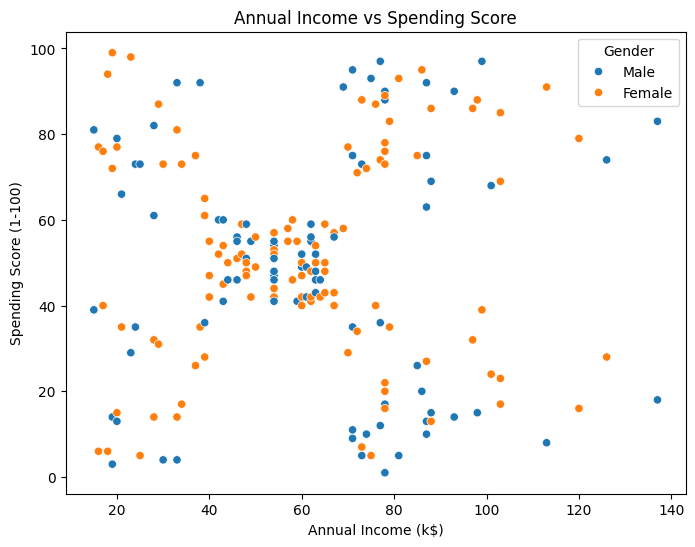

In [15]:
# Scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=customers_data)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.show()

In [16]:
# One-hot encoding Gender column
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_gender = encoder.fit_transform(customers_data[['Gender']])
customers_data = customers_data.drop(columns=['Gender'])
customers_data['Gender_Male'] = encoded_gender
print(customers_data.head())

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0           1   19                  15                      39          1.0
1           2   21                  15                      81          1.0
2           3   20                  16                       6          0.0
3           4   23                  16                      77          0.0
4           5   31                  17                      40          0.0


In [17]:
# Scale numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customers_data.drop(columns=['CustomerID']))


In [18]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)


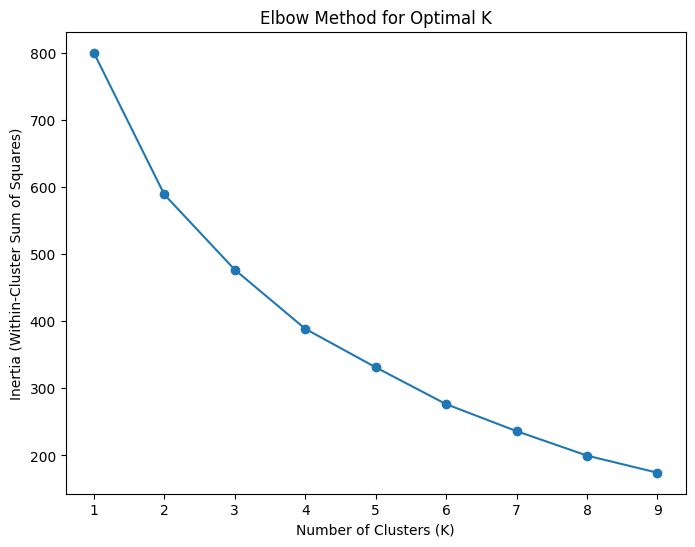

In [19]:
# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.show()

In [20]:
# Apply K-Means clustering with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
customers_data['Cluster'] = kmeans.fit_predict(scaled_features)


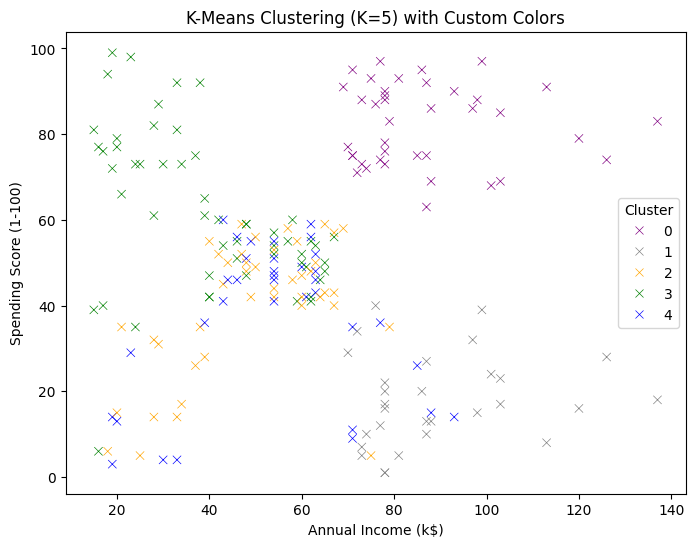

In [28]:
# Define custom colors for each cluster
custom_palette = {0: 'purple', 1: 'grey', 2: 'orange', 3: 'green', 4: 'blue'}

# Create scatter plot with custom colors
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue=customers_data['Cluster'],
                palette=custom_palette,
                data=customers_data)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering (K=5) with Custom Colors")
plt.legend(title="Cluster")
plt.show()


## Customer Segmentation Insights (K-Means Clustering - K=5)

### Cluster 0 (Purple):
- **High-income earners with high spending scores**
- These customers bring in significant revenue to the store.
- **Strategy:** Discounts and exclusive offers can increase their spending further and maximize profit.

### Cluster 1 (Yellow):
- **Average income earners with average spending scores**
- These customers are cautious with their spending and do not overspend.
- **Strategy:** Introducing loyalty programs or bundle deals may encourage them to spend more.

### Cluster 2 (Gray):
- **Higher-income customers but with lower spending scores**
- They have the potential to spend more but are not currently engaged with the store.
- **Strategy:** Investigate potential dissatisfaction or offer premium services to capture their attention.

### Cluster 3 (Green):
- **Low-income earners with low spending scores**
- Due to lower income, their spending at the store remains minimal.
- **Strategy:** Providing budget-friendly options and discounts could help retain these customers.

### Cluster 4 (Blue):
- **Low-income customers with high spending scores**
- Despite lower income, these customers spend a lot at the store.
- **Strategy:** Ensure a great customer experience and retain them with rewards or exclusive deals.

## Actionable Business Strategies
- **High-Income, High-Spend Customers (Purple)** → Reward loyalty, exclusive deals.
- **Average Earners (Yellow)** → Encourage spending with combo offers or store memberships.
- **High-Income, Low-Spend (Gray)** → Improve customer engagement, resolve dissatisfaction.
- **Low-Income, Low-Spend (Green)** → Offer budget-friendly items, discounts.
- **Low-Income, High-Spend (Blue)** → Maintain satisfaction, retain with rewards.


In [23]:
# Create a 3D interactive plot using Plotly
fig = px.scatter_3d(customers_data,
                    x='Annual Income (k$)',
                    y='Spending Score (1-100)',
                    z='Age',
                    color=customers_data['Cluster'].astype(str),
                    title="Interactive 3D K-Means Clustering Visualization (K=5)",
                    labels={'Cluster': 'Cluster'},
                    opacity=0.7)

# Save as an interactive HTML file
html_file_path = "kmeans_customers_3d_plot.html"
fig.write_html(html_file_path)

print(f"3D interactive plot saved as: {html_file_path}")


ValueError: The palette dictionary is missing keys: {'green', 'red', 'purple', 'blue', 'yellow'}

<Figure size 800x600 with 0 Axes>

Business Insights
The result of the analysis shows that the retail store customers can be group into 5 clusters or segments for targeted marketing.

Cluster 0 (green): These are average income earners with average spending scores. They are cautious with their spending at the store.

Cluster 2 (yellow): The customers in this group are high income earners and with high spending scores. They bring in profit. Discounts and other offers targeted at this group will increase their spending score and maximize profit.

Cluster 3 (red): This group of customers have a higher income but they do not spend more at the store. One of the assumption could be that they are not satisfied with the services rendered at the store. They are another ideal group to be targeted by the marketing team because they have the potential to bring in increased profit for the store.

Cluster 4 (purple): Low income earners with low spending score. I can assume that this is so because people with low income will tend to purchase less item at the store.

Cluster 5 (blue): These are low income earning customers with high spending scores. I can assume that why this group of customers spend more at the retail store despite earning less is because they enjoy and are satisfied with the services rendered at the retail store.